# Data Collect


### Import Dataset

In [31]:
import pandas as pd

ans = pd.read_csv("anies.csv", encoding='latin-1')
gjr = pd.read_csv("ganjar.csv", encoding='latin-1')
pbw = pd.read_csv("prabowo.csv", encoding='latin-1')

In [32]:
ans.head(3)

,Unnamed: 0.1,Date,Created,User ID,Followers,Following,Tweet Count,TweetLocation,Text,label
0,0,2023-04-16 10:04:35+00:00,2023-03-27 08:59:57+00:00,1640000000000000000,981,531,22,NaN,anies president info,Positive
1,1,2023-04-16 10:00:01+00:00,2012-08-21 07:34:04+00:00,771030588,10702,123,30121,"Palmerah, Jakarta",gerindra party politician sandiaga uno answers...,Positive
2,2,2023-04-16 09:14:46+00:00,2011-09-27 05:22:24+00:00,380755133,11,35,230,North Jakarta,"mr. anies continued, we will guard him until h...",Positive


In [33]:
gjr.head(3)

,Unnamed: 0,Date,Created,User ID,Followers,Following,Tweet Count,TweetLocation,Text,label
0,0,2023-04-16 09:04:01+00:00,2016-05-28 16:50:39+00:00,737000000000000000,2358,3001,13665,Indonesia,"ganjar is getting more and more support, now s...",Positive
1,1,2023-04-16 08:31:02+00:00,2023-03-31 05:48:36+00:00,1640000000000000000,374,599,621,No Place to KADRUN,ojoo lali yooo who is smart chooses pranowo's ...,Positive
2,2,2023-04-16 08:00:00+00:00,2023-03-31 05:48:36+00:00,1640000000000000000,374,599,621,No Place to KADRUN,smart people support and reward pranowo well,Positive


In [34]:
pbw.head(3)

,Unnamed: 0.1,Date,Created,User ID,Followers,Following,Tweet Count,TweetLocation,Text,label
0,0,2023-04-16 09:44:01+00:00,2018-07-07 09:43:19+00:00,1020000000000000000,477,337,12568,Khoiril Anwar,gemira and semeton bali muslims declare suppor...,Positive
1,1,2023-04-16 09:27:10+00:00,2019-10-29 04:40:11+00:00,1190000000000000000,27910,20171,63723,NaN,fahnoor inismyname that's why we support the p...,Negative
2,2,2023-04-16 08:32:06+00:00,2022-12-16 05:02:00+00:00,1600000000000000000,144,114,6596,NaN,"this time, jokowi's quota for wrinkles on his ...",Positive


### Gabungkan Dataset

In [35]:
gjr = gjr.rename(columns={'Unnamed: 0': 'No.'})
ans = ans.rename(columns={'Unnamed: 0.1': 'No.'})
pbw = pbw.rename(columns={'Unnamed: 0.1': 'No.'})

In [36]:
ans['Kandidat'] = "Anies"
pbw['Kandidat'] = "Prabowo"
gjr['Kandidat'] = "Ganjar"

In [37]:
data = pd.concat([ans, gjr, pbw], ignore_index=True)
data.head()

,No.,Date,Created,User ID,Followers,Following,Tweet Count,TweetLocation,Text,label,Kandidat
0,0,2023-04-16 10:04:35+00:00,2023-03-27 08:59:57+00:00,1640000000000000000,981,531,22,NaN,anies president info,Positive,Anies
1,1,2023-04-16 10:00:01+00:00,2012-08-21 07:34:04+00:00,771030588,10702,123,30121,"Palmerah, Jakarta",gerindra party politician sandiaga uno answers...,Positive,Anies
2,2,2023-04-16 09:14:46+00:00,2011-09-27 05:22:24+00:00,380755133,11,35,230,North Jakarta,"mr. anies continued, we will guard him until h...",Positive,Anies
3,3,2023-04-16 07:03:05+00:00,2017-10-19 12:32:28+00:00,921000000000000000,37,47,2670,Jakarta,may allah swt save the nation and state of the...,Positive,Anies
4,4,2023-04-16 06:03:59+00:00,2022-06-28 07:03:37+00:00,1540000000000000000,6,129,766,"Lebak, Banten","poor chotimah, uncle anies, that's why my fami...",Positive,Anies


### Ambil Data Januari 2023-April 2023

In [38]:
data.columns = data.columns.str.strip()

In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   No.            30000 non-null  int64
 1   Date           30000 non-null  str  
 2   Created        30000 non-null  str  
 3   User ID        30000 non-null  int64
 4   Followers      30000 non-null  int64
 5   Following      30000 non-null  int64
 6   Tweet Count    30000 non-null  int64
 7   TweetLocation  13805 non-null  str  
 8   Text           29731 non-null  str  
 9   label          29997 non-null  str  
 10  Kandidat       30000 non-null  str  
dtypes: int64(5), str(6)
memory usage: 2.5 MB


In [40]:
data['Date'] = data['Date'].str.strip()
data['Date'] = pd.to_datetime(data['Date'])

In [41]:
data = data[data['Date'] >= '2023-01-01']

In [42]:
data['Kandidat'].value_counts()

Kandidat
Anies      10000
Prabowo     9417
Ganjar      5159
Name: count, dtype: int64

In [43]:
hasil = []

for kandidat, df_k in data.groupby('Kandidat'):

    # Hitung proporsi tiap label
    proporsi = df_k['label'].value_counts(normalize=True)

    n_pos = round(proporsi['Positive'] * 5159)
    n_neg = 5159 - n_pos

    pos = df_k[df_k['label'] == 'Positive'].sample(
        n=n_pos, random_state=42
    )

    neg = df_k[df_k['label'] == 'Negative'].sample(
        n=n_neg, random_state=42
    )

    hasil.append(pd.concat([pos, neg]))

data = pd.concat(hasil).sample(frac=1, random_state=42).reset_index(drop=True)

# Data Understanding
shape, head, tipe data, statistik deskriptif, desribe object, visualisasi distribusi target, distribusi numerik, analisis korelasi,

In [15]:
data.shape

(15477, 11)

### Statistik deskriptif

In [46]:
data.describe()

,No.,User ID,Followers,Following,Tweet Count
count,15477.000000,1.547700e+04,1.547700e+04,15477.000000,1.547700e+04
mean,4071.567681,1.183387e+18,7.318898e+04,783.038832,3.220944e+04
std,2664.036399,5.954622e+17,9.397614e+05,2310.018384,1.626753e+05
min,0.000000,1.432172e+07,0.000000e+00,0.000000,1.000000e+00
25%,1858.000000,1.060000e+18,2.300000e+01,29.000000,5.590000e+02
50%,3738.000000,1.490000e+18,7.900000e+01,108.000000,2.459000e+03
75%,6009.000000,1.590000e+18,3.680000e+02,386.000000,1.397800e+04
max,9999.000000,1.650000e+18,2.018897e+07,34848.000000,2.310131e+06


In [47]:
data.describe(include='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_13608\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,Created,TweetLocation,Text,label,Kandidat
count,15477,6982,15302,15477,15477
unique,4765,902,12045,2,3
top,2022-02-15 12:04:06+00:00,Indonesia,prabowo is president,Positive,Prabowo
freq,855,1426,54,11039,5159


## Visualisasi
distribusi sentimen tiap kandidat, tren waktu sentimen, follower vs tweet count, tren waktu tweet, distribusi umur akun

### Sentimen per kandidat

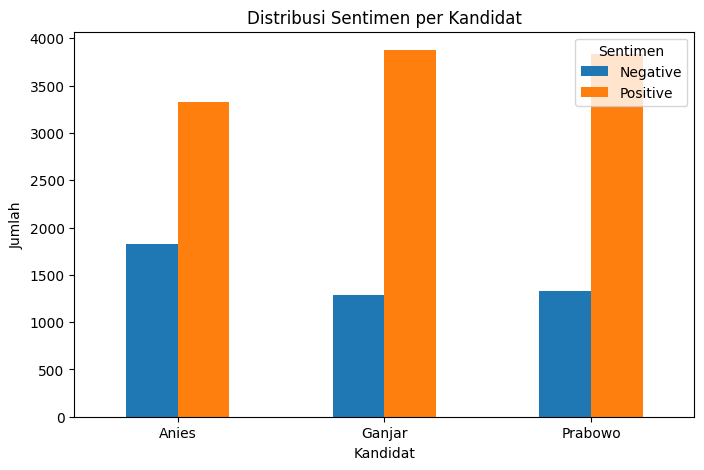

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

sentimen = pd.crosstab(data['Kandidat'], data['label'])
sentimen.plot(kind='bar', figsize=(8,5))

plt.title('Distribusi Sentimen per Kandidat')
plt.xlabel('Kandidat')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.legend(title='Sentimen')
plt.show()

### Tren waktu sentimen

C:\Users\DELL\AppData\Local\Temp\ipykernel_13608\1994630795.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tren = data.groupby(data['Date'].dt.to_period('M')).size()


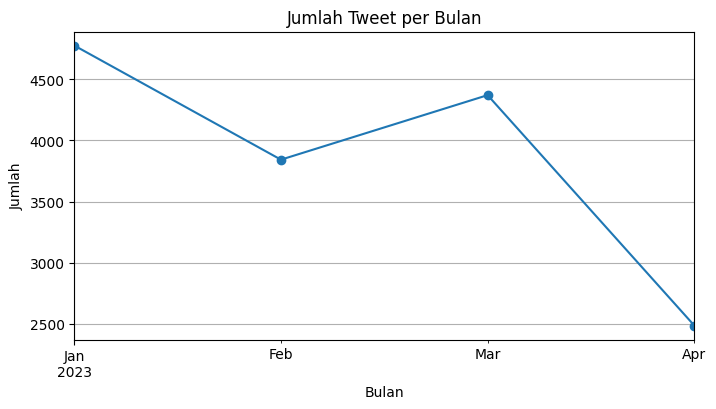

In [50]:
import matplotlib.pyplot as plt

tren = data.groupby(data['Date'].dt.to_period('M')).size()

plt.figure(figsize=(8,4))
tren.plot(kind='line', marker='o')
plt.title('Jumlah Tweet per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah')
plt.grid(True)
plt.show()

### Tren Umur Akun

C:\Users\DELL\AppData\Local\Temp\ipykernel_13608\3948016843.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tren = data.groupby(data['Created'].dt.to_period('M')).size()


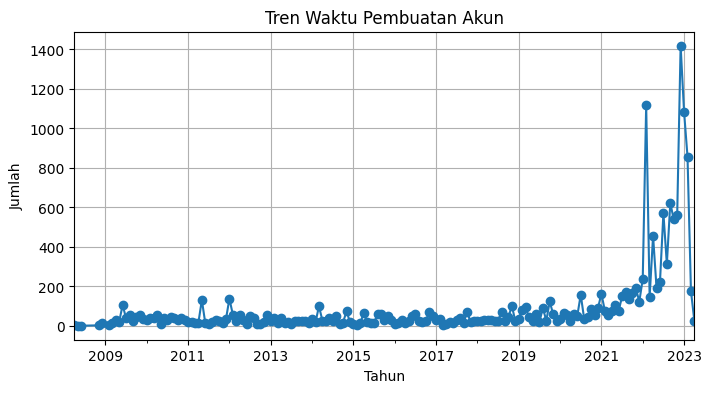

In [51]:
tren = data.groupby(data['Created'].dt.to_period('M')).size()

plt.figure(figsize=(8,4))
tren.plot(kind='line', marker='o')
plt.title('Tren Waktu Pembuatan Akun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah')
plt.grid(True)
plt.show()

### Follower vs tweet count

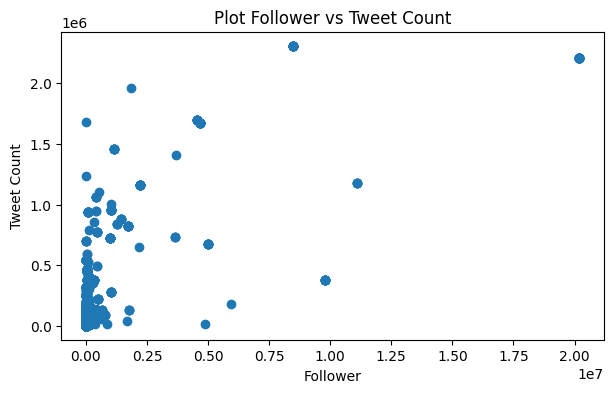

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.scatter(data['Followers'], data['Tweet Count'])
plt.title('Plot Follower vs Tweet Count')
plt.xlabel('Follower')
plt.ylabel('Tweet Count')
plt.show()

### Umur akun vs tweet count

In [53]:
plt.figure(figsize=(7,4))
plt.scatter(data['UmurAkun'], data['Tweet Count'])
plt.title('Plot Umur Akun vs Tweet Count')
plt.xlabel('Umur Akun (hari)')
plt.ylabel('Tweet Count')
plt.show()

KeyError: 'UmurAkun'

<Figure size 700x400 with 0 Axes>

### bot vs not

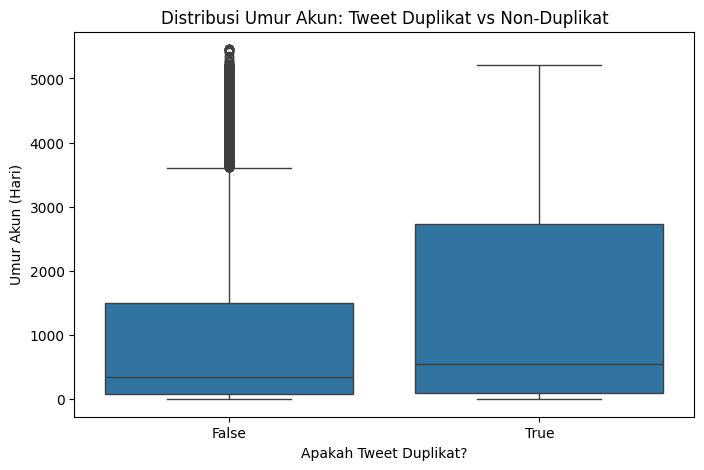

In [ ]:
# Tandai mana baris yang merupakan duplikat
data['Is_Duplicate'] = data.duplicated(subset=['User ID', 'Tweet', 'Date'], keep=False)

# Plot menggunakan seaborn (Boxplot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x='Is_Duplicate', y='UmurAkun', data=data)
plt.title('Distribusi Umur Akun: Tweet Duplikat vs Non-Duplikat')
plt.xlabel('Apakah Tweet Duplikat?')
plt.ylabel('Umur Akun (Hari)')
plt.show()

### Distribusi umur akun

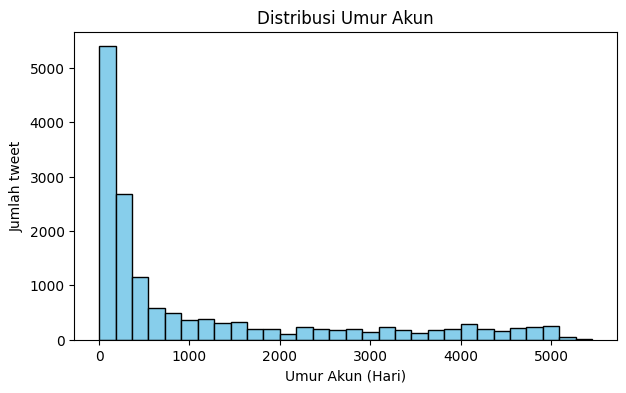

In [ ]:
data['UmurAkun'] = (data['Date'] - data['Created']).dt.days

plt.figure(figsize=(7,4))
plt.hist(data['UmurAkun'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Umur Akun')
plt.xlabel('Umur Akun (Hari)')
plt.ylabel('Jumlah tweet')
plt.show()

## Kesimpulan
ubah date created dri object ke datetime, user id dri float ke object.

ada missing value di tweet location dan text dan label

# Data Preparation
formatting, Handling missing value, duplicate data, outliers, typo data, split data, encoding, feature selection

### Formatting

In [44]:
data.dtypes

No.                            int64
Date             datetime64[us, UTC]
Created                          str
User ID                        int64
Followers                      int64
Following                      int64
Tweet Count                    int64
TweetLocation                    str
Text                             str
label                            str
Kandidat                         str
dtype: object

In [45]:
data['User ID'] = data['User ID'].astype(str)

In [46]:
data['Created'] = data['Created'].str.strip()
data['Created'] = pd.to_datetime(data['Created'], utc=True)

### Handling missing value

In [47]:
data.isnull().sum()

No.                 0
Date                0
Created             0
User ID             0
Followers           0
Following           0
Tweet Count         0
TweetLocation    8495
Text              175
label               0
Kandidat            0
dtype: int64

In [48]:
data = data.dropna(subset=['Text'])
data['TweetLocation'] = data['TweetLocation'].fillna('-')

In [49]:
data.shape

(15302, 11)

### Duplicate data

In [50]:
data.duplicated().sum()

np.int64(0)

In [51]:
data[['User ID', 'Text', 'Date']].duplicated().sum()

np.int64(565)

In [52]:
data = data.drop_duplicates(
    subset=['User ID', 'Text', 'Date']
)

In [53]:
data.shape

(14737, 11)

### Inconsistency Data

In [54]:
data['label'].value_counts(dropna=False)

label
Positive    10660
Negative     4077
Name: count, dtype: int64

### Feature Selection

In [55]:
data = data[['Text', 'label']]

In [56]:
data.head()

,Text,label
0,continued success and hopefully mr prabowo wil...,Positive
1,aminanies baswedan was approved by many partie...,Positive
2,steadfast anies president,Positive
3,jokowi is excited to support prabowo subianto ...,Positive
4,chotimah yes deh nul rewards presidential cand...,Positive


# Preprocessing Text

### Cleaning

In [57]:
import re

def clean(text):
  text = text.lower()
  text = re.sub(r'http\S+|www\.\S+', '', text) # link
  text = re.sub(r'@\w+', '', text)    # mention
  text = re.sub(r'#', '', text)       # hashtag
  text = re.sub(r'\d+', '', text)     # angka
  text = re.sub(r'[^a-zA-Z\s]', '', text)   # tanda baca & simbol
  text = re.sub(r'\s+', ' ', text).strip()  # spasi berlebih
  return text

data['Clean'] = data['Text'].astype(str).apply(clean)
data.head()

,Text,label,Clean
0,continued success and hopefully mr prabowo wil...,Positive,continued success and hopefully mr prabowo wil...
1,aminanies baswedan was approved by many partie...,Positive,aminanies baswedan was approved by many partie...
2,steadfast anies president,Positive,steadfast anies president
3,jokowi is excited to support prabowo subianto ...,Positive,jokowi is excited to support prabowo subianto ...
4,chotimah yes deh nul rewards presidential cand...,Positive,chotimah yes deh nul rewards presidential cand...


### Tokenization

In [58]:
data['Tokenization'] = data['Clean'].apply(lambda x: x.split())
data.head(3)

,Text,label,Clean,Tokenization
0,continued success and hopefully mr prabowo wil...,Positive,continued success and hopefully mr prabowo wil...,"[continued, success, and, hopefully, mr, prabo..."
1,aminanies baswedan was approved by many partie...,Positive,aminanies baswedan was approved by many partie...,"[aminanies, baswedan, was, approved, by, many,..."
2,steadfast anies president,Positive,steadfast anies president,"[steadfast, anies, president]"


### Stopword removal

In [59]:
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
data['Stopwords'] = data['Tokenization'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words])
data.head(3)

,Text,label,Clean,Tokenization,Stopwords
0,continued success and hopefully mr prabowo wil...,Positive,continued success and hopefully mr prabowo wil...,"[continued, success, and, hopefully, mr, prabo...","[continued, success, hopefully, mr, prabowo, b..."
1,aminanies baswedan was approved by many partie...,Positive,aminanies baswedan was approved by many partie...,"[aminanies, baswedan, was, approved, by, many,...","[aminanies, baswedan, approved, many, parties,..."
2,steadfast anies president,Positive,steadfast anies president,"[steadfast, anies, president]","[steadfast, anies, president]"


### Lemmatization

In [60]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
data['Lemma'] = data['Stopwords'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)


In [61]:
data['Processed'] = data['Lemma'].apply(' '.join)
data.head(3)

,Text,label,Clean,Tokenization,Stopwords,Lemma,Processed
0,continued success and hopefully mr prabowo wil...,Positive,continued success and hopefully mr prabowo wil...,"[continued, success, and, hopefully, mr, prabo...","[continued, success, hopefully, mr, prabowo, b...","[continued, success, hopefully, mr, prabowo, b...",continued success hopefully mr prabowo blessin...
1,aminanies baswedan was approved by many partie...,Positive,aminanies baswedan was approved by many partie...,"[aminanies, baswedan, was, approved, by, many,...","[aminanies, baswedan, approved, many, parties,...","[aminanies, baswedan, approved, many, party, v...",aminanies baswedan approved many party various...
2,steadfast anies president,Positive,steadfast anies president,"[steadfast, anies, president]","[steadfast, anies, president]","[steadfast, anies, president]",steadfast anies president


### TF-IDF

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,  # ambil 5000 fitur teratas berdasarkan skor TF-IDF
    ngram_range=(1, 2) # ambil unigrams dan bigrams
)
X = tfidf.fit_transform(data['Processed'])
y = data['label']

### Split data

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(11789, 5000)
(2948, 5000)
label
Positive    8528
Negative    3261
Name: count, dtype: int64
label
Positive    2132
Negative     816
Name: count, dtype: int64


In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"ada {len(tfidf.get_feature_names_out())} kata unik")

AttributeError: 'csr_matrix' object has no attribute 'lower'

In [ ]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 369608 stored elements and shape (22740, 22495)>

# Modeling & Evaluation

### Logistic Regression
Mampu memanfaatkan bobot TF-IDF dengan baik sehingga lebih efektif dalam membedakan sentimen.

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", acc_lr)
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8568521031207599
              precision    recall  f1-score   support

    Negative       0.81      0.63      0.71       816
    Positive       0.87      0.94      0.91      2132

    accuracy                           0.86      2948
   macro avg       0.84      0.79      0.81      2948
weighted avg       0.85      0.86      0.85      2948



### SVM
SVM memiliki kemampuan terbaik dalam mengklasifikasi sentimen. SVM memang dikenal efektif untuk klasifikasi data teks berdimensi tinggi.

In [66]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy :", acc_svm)

print(classification_report(y_test, y_pred_svm))

Accuracy : 0.8687245590230664
              precision    recall  f1-score   support

    Negative       0.76      0.76      0.76       816
    Positive       0.91      0.91      0.91      2132

    accuracy                           0.87      2948
   macro avg       0.84      0.84      0.84      2948
weighted avg       0.87      0.87      0.87      2948



# Kesimpulan
Berdasarkan hasil evaluasi, model SVM memberikan performa terbaik dengan accuracy 91,26%, precision 91,18%, recall 91,26%, dan F1 score 91,21%.